## Free Throw Model — Training/Testing Pipeline

### Prerequisites: 
* Run feature engineering scripts (extract_phase_features.py and prepare_phase_dataset.py) to get features. 

### Machine Learning Pipeline:
- #### **Step 1** Split data between training/validation and testing
    - Right now I’m using 80% of the data for training/validation and 20% for testing.
- #### **Step 2** Hyperparemeter Tuning 
    - k fold cross validation and a grid search to find the hyperparameters for each model that optimize f1 score
- #### **Step 3** Calibration/Thresholding on best CV models
    - **calibration** methods:
        - sigmoid
        - isotonic 
        - none
    - two **thresholding** methods: 
        - highest F1 score possible
        - F1 score measured at the threshold where precision is constrained to 70%
- #### **Step 4** Final Training and Testing
    - train best performing models on all training data
    - plot confusion matrices, reliability curves, and precision recall curves 
- #### **Step 5** Diagnostics of Final Models
    - Test the model on the 20% testing data and see how it does on data that it has not seen before
- #### **Step 6** Feature Pruning
    - From permutation Importance

In [82]:
# =================================================
# Create unique experiment directory 
# =================================================

from datetime import datetime
import re
from pathlib import Path
import yaml

PROJECT_ROOT = Path().resolve().parent # go up one level

# Load feature config
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"]
MODEL_TYPE = feature_config["model_type"]   # "summary_stats" or "time_series"

# --- makes label for the experiment ---
def start_run(label: str = "baseline") -> Path:
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    # put MODEL_TYPE under experiments
    root = PROJECT_ROOT / "experiments" / MODEL_TYPE
    root.mkdir(parents=True, exist_ok=True)
    
    existing = sorted(root.glob(f"{ts}_run-*_{label}"))
    idx = 1
    if existing:
        m = re.search(r"_run-(\d{3})_", existing[-1].name)
        idx = (int(m.group(1)) + 1) if m else 1
    
    rd = root / f"{ts}_run-{idx:03d}_{label}"
    rd.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] Run directory: {rd}")
    return rd

run_dir = start_run("baseline")

[INFO] Run directory: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline


In [84]:

# =================================================
# Step 0: Import Libraries and Create Models
# =================================================

from __future__ import annotations
from pathlib import Path
from joblib import dump, load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import re

# --- sklearn ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score, average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score as _f1_for_perm
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.metrics import make_scorer, f1_score, average_precision_score, brier_score_loss

from sklearn.metrics import (
    precision_recall_fscore_support, average_precision_score,
    roc_auc_score, brier_score_loss
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    average_precision_score, roc_auc_score
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix
)

# --- Plotting Util (saves CM, PR, calibration) ---
from plots import save_all_eval_figures

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --- Load Project Config ---
project_cfg_path = PROJECT_ROOT / "project_config.yaml"
with open(project_cfg_path, "r") as f:
    project_config = yaml.safe_load(f)

ATHLETE = project_config["athlete"]
SESSION = project_config["session"]

LABELS = ["miss", "make"]                # row/col order in CM: 0->miss, 1->make
LABEL_TO_INT = {"miss": 0, "make": 1}
INT_TO_LABEL = {0: "miss", 1: "make"}

POS_LABEL = "miss"                        # human-friendly
POS_LABEL_INT = LABEL_TO_INT[POS_LABEL]   # = 0  (positive class is miss)

# --- Load Feature Config ---
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"] # version of feature data set 
MODEL_TYPE = feature_config["model_type"] # summary_stats or time_series

# --- Paths and Directories ---
DATA_ROOT = PROJECT_ROOT / "data" / ATHLETE

SESSIONS = {
    "session_01": DATA_ROOT / "session_01" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_02": DATA_ROOT / "session_02" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_03": DATA_ROOT / "session_03" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_04": DATA_ROOT / "session_04" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION
    # add more sessions here...
}

In [96]:
# =================================================
# Step 1: Split data into train/validation and test
# =================================================

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
session_train_list, session_test_list = [], []

for session_name, base in SESSIONS.items():
    # Load
    X = pd.read_csv(base / "X.csv")
    y = pd.read_csv(base / "y.csv").squeeze("columns").astype(int)

    # Stratify class proportions based on y (makes/misses)
    strat = y if y.nunique() > 1 else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=strat 
    )

    # Store with session labels
    X_train_list.append(X_tr) 
    X_test_list.append(X_te)
    y_train_list.append(y_tr)
    y_test_list.append(y_te)
    session_train_list.extend([session_name] * len(y_tr))
    session_test_list.extend([session_name] * len(y_te))

# Concatenate everything
X_train = pd.concat(X_train_list, ignore_index=True)
X_test  = pd.concat(X_test_list, ignore_index=True)
y_train = pd.concat(y_train_list, ignore_index=True)
y_test  = pd.concat(y_test_list, ignore_index=True)
session_train = pd.Series(session_train_list, name="session")
session_test  = pd.Series(session_test_list, name="session")

# Print feature names
print("\n[FEATURES included]")
for i, col in enumerate(X_train.columns, start=1):
    print(f"{i:3d}. {col}")

# print shape and counts
print("[INFO] Train shape:", X_train.shape, "Test shape:", X_test.shape)
name_map = {0: "miss", 1: "make"}

print("\n[TRAIN counts]")
train_counts = pd.crosstab(session_train, y_train.map(name_map), margins=True, margins_name="Total")
print(train_counts)

print("\n[TEST counts]")
test_counts = pd.crosstab(session_test, y_test.map(name_map), margins=True, margins_name="Total")
print(test_counts)




[FEATURES included]
  1. windup_duration
  2. follow_duration
  3. total_duration
  4. elbow_flex_l_release_value
  5. elbow_flex_r_release_value
  6. shoulder_flex_l_release_value
  7. shoulder_flex_r_release_value
  8. hip_flex_l_release_value
  9. hip_flex_r_release_value
 10. knee_flex_l_release_value
 11. knee_flex_r_release_value
 12. ankle_flex_l_release_value
 13. ankle_flex_r_release_value
[INFO] Train shape: (399, 13) Test shape: (101, 13)

[TRAIN counts]
_label      make  miss  Total
session                      
session_01     5    10     15
session_02    52    27     79
session_03    92    53    145
session_04   110    50    160
Total        259   140    399

[TEST counts]
_label      make  miss  Total
session                      
session_01     1     3      4
session_02    13     7     20
session_03    23    14     37
session_04    27    13     40
Total         64    37    101


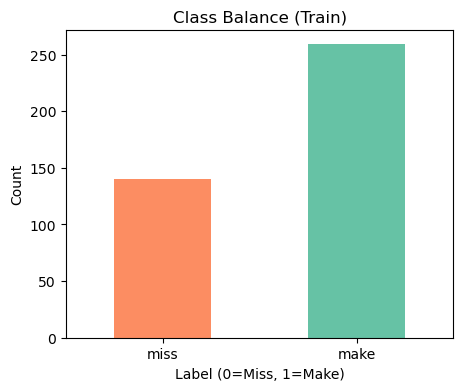

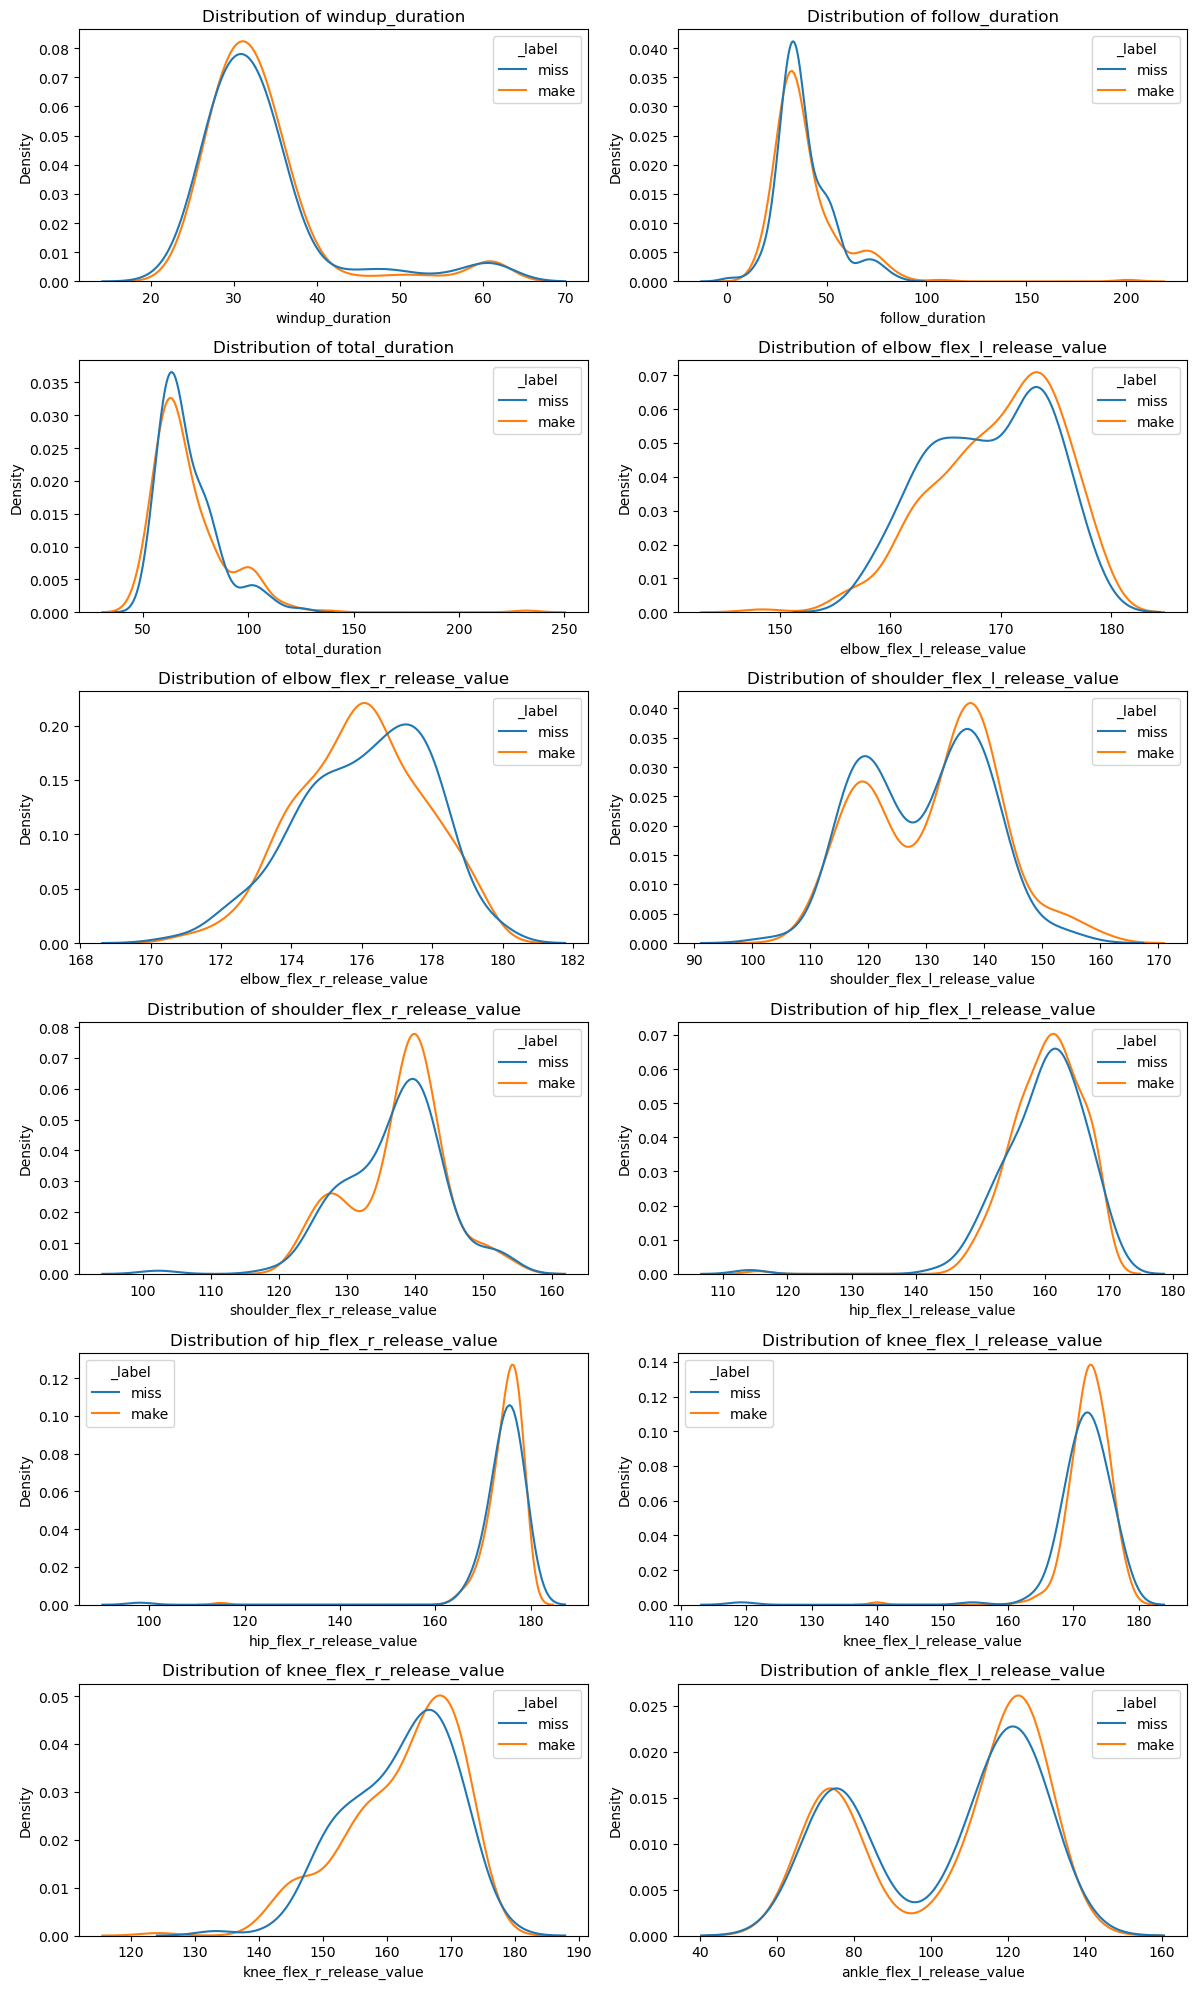

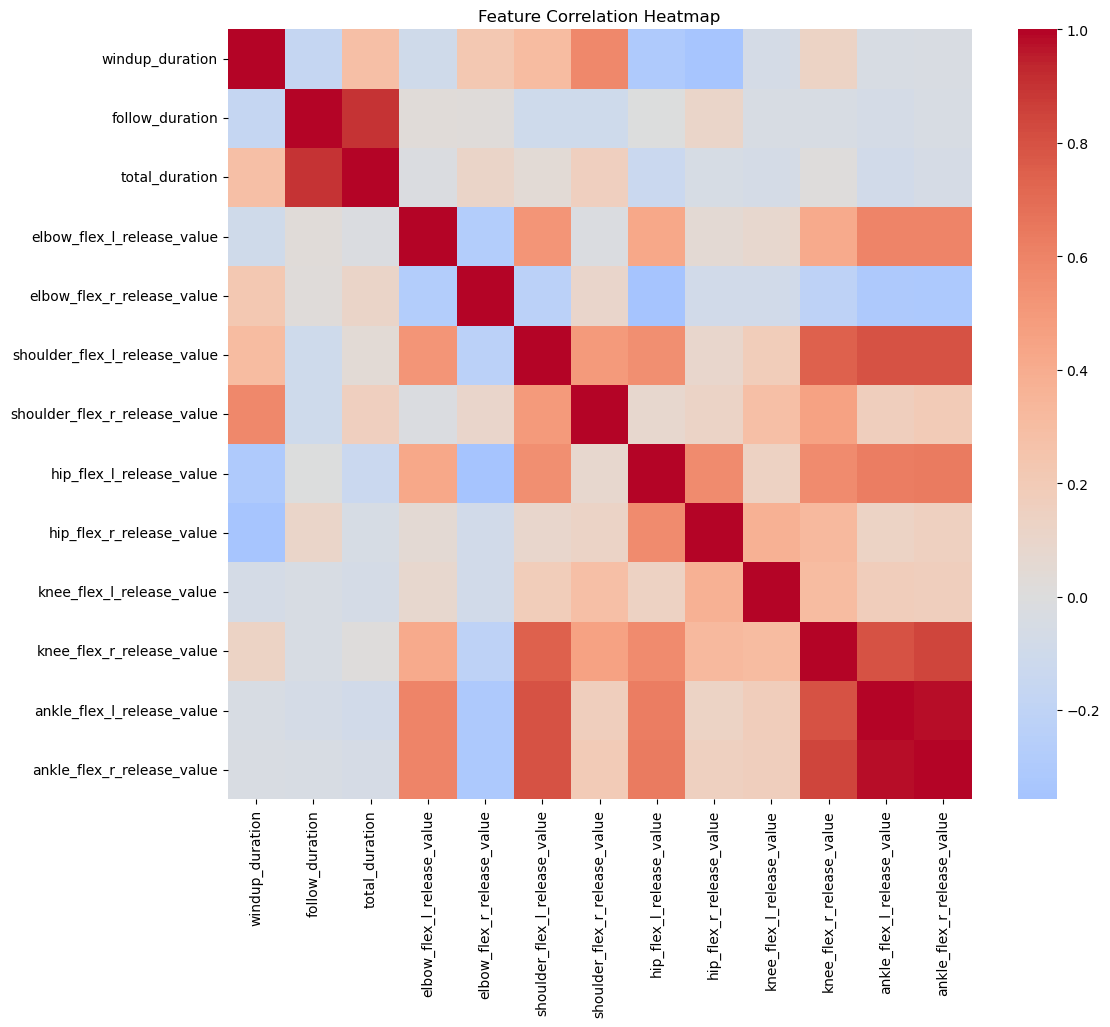

In [86]:
# =================================================
# A. Pre-Modeling EDA
# =================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --- Class balance ---
plt.figure(figsize=(5,4))
y_train.value_counts().sort_index().plot(
    kind="bar", color=["#fc8d62", "#66c2a5"]
)
plt.title("Class Balance (Train)")
plt.xlabel("Label (0=Miss, 1=Make)")
plt.ylabel("Count")
plt.xticks([0, 1], ["miss", "make"], rotation=0)  # show names
plt.show()

# --- Feature distributions ---
y_train_named = y_train.map({0: "miss", 1: "make"})

num_cols = X_train.columns  # or slice if you want
fig, axes = plt.subplots(len(num_cols)//2, 2, figsize=(12, 20))

for ax, col in zip(axes.flatten(), num_cols):
    sns.kdeplot(data=X_train, x=col, hue=y_train_named,
                common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


# --- Correlation heatmap ---
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [87]:
# =================================================
# Step 2: Tune model hyperparameters
# =================================================

# --- score extractors that respect POS_LABEL and work with Pipelines ---

def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if isinstance(est, Pipeline):
        return _classes_of(est.steps[-1][1])
    if hasattr(est, "best_estimator_"):
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def get_pos_scores(est, X, pos_label):
    # Prefer predict_proba; fallback to decision_function
    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(X)
        classes = list(_classes_of(est))
        idx = classes.index(pos_label)
        return proba[:, idx]
    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        classes = list(_classes_of(est))
        if df.ndim == 1:
            return df if pos_label == classes[1] else -df
        idx = classes.index(pos_label)
        return df[:, idx]
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def ap_pos_scorer(est, X, y):
    s = get_pos_scores(est, X, POS_LABEL_INT)
    return average_precision_score(y, s, pos_label=POS_LABEL_INT)

def roc_pos_scorer(est, X, y):
    s = get_pos_scores(est, X, POS_LABEL_INT)
    return roc_auc_score(y, s)


# MODELS dict: define the 7 classifiers you want to compare
# - class_weight="balanced" helps when dataset is imbalanced 
MODELS = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,      # allow more iterations to ensure convergence
        solver="lbfgs",     # recommended solver for small/medium datasets
        class_weight="balanced"
    ),
    "KNN": KNeighborsClassifier(),  # needs scaling, handled in pipeline
    "DecisionTree": DecisionTreeClassifier(
        random_state=42,    # reproducibility
        class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,   # number of trees
        random_state=42,
        class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
        # no class_weight support here; handle imbalance via sample_weight if needed
    ),
    "SVM": SVC(
        kernel="rbf",       # nonlinear kernel
        probability=True,   # enables predict_proba (slower but needed for metrics like AP/Brier/LogLoss)
        class_weight="balanced",
        random_state=42
    ),
    "LinearSVC": LinearSVC(
        C=1.0,
        max_iter=10000,     # iterations; may need increasing if convergence warnings appear
        tol=1e-3,           # tolerance for stopping criterion
        class_weight="balanced"
    ),
}

# =================================================
# Pipelines: wrap each model in preprocessing steps if needed
# =================================================
# - Models like LogisticRegression, KNN, SVM, LinearSVC are sensitive to feature scales → add StandardScaler
# - Tree-based models (DecisionTree, RF, GB) are scale-invariant → no scaler
pipelines = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["LogisticRegression"])
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["KNN"])
    ]),
    "DecisionTree": Pipeline([
        ("clf", MODELS["DecisionTree"])
    ]),
    "RandomForest": Pipeline([
        ("clf", MODELS["RandomForest"])
    ]),
    "GradientBoosting": Pipeline([
        ("clf", MODELS["GradientBoosting"])
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["SVM"])
    ]),
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["LinearSVC"])
    ]),
}

# =================================================
# Hyperparameter grids for each model
# =================================================
# These define the search space for GridSearchCV.
# Adjust ranges based on dataset size
# Currently set for ~ 500 clips 

n_samples, n_features = X_train.shape
LINSVC_DUAL = (n_features > n_samples)  # True if p>n; False if n>p

param_grids = {
    "LogisticRegression": {
        "clf__C": [0.1, 1.0, 10.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
    },

    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],                
        "clf__leaf_size": [15, 30],  
    },

    "DecisionTree": {
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__max_features": [None, "sqrt"],
    },

    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5],
        "clf__max_features": ["sqrt", "log2"],
    },

    "GradientBoosting": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.7, 1.0],    
    },

    "SVM": {
        "clf__C": [0.3, 1.0, 3.0],
        "clf__gamma": ["scale"],
    },

    "LinearSVC": {
        "clf__C": [0.1, 1.0, 3.0],
        "clf__loss": ["squared_hinge"],
        "clf__tol": [1e-3],
        "clf__max_iter": [20000, 50000],
        "clf__dual": [LINSVC_DUAL],
    },
}

# =================================================
# CV splitter and scoring metrics
# =================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # StratifiedKFold preserves class distribution across folds.
# TODO maybe use GroupKFold in the future

scoring = {
    "f1_pos": make_scorer(f1_score, pos_label=POS_LABEL_INT),
    "ap_pos": ap_pos_scorer,
    "roc":    roc_pos_scorer,
}


# =================================================
# Grid Search loop
# =================================================
leaderboard_rows = []
best_models = {}

for name, pipe in pipelines.items():
    print(f"\n=== Tuning {name} ===")
    
    grid = GridSearchCV(
        estimator=pipe,              # the pipeline to tune
        param_grid=param_grids[name],# hyperparameter search space
        cv=cv,                       # cross-validation strategy
        scoring=scoring,             # all metrics in dict
        refit="f1_pos",              # choose final model based on this metric
        n_jobs=-1,                   # use all CPUs for speed
        verbose=0,                   # 0 = silent, >0 = more logging per fit
        return_train_score=False,     # don’t store train scores (saves memory)
        error_score=np.nan
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_  # store the best-tuned pipeline

    # --- derive precision/recall for POS_LABEL from CV predictions ---
    y_pred = grid.best_estimator_.predict(X_train)
    prec = precision_score(y_train, y_pred, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_train, y_pred, pos_label=POS_LABEL_INT, zero_division=0)

    # Extract leaderboard info
    row = {
        "model": name,
        "best_params": grid.best_params_,
        "cv_f1":  grid.cv_results_["mean_test_f1_pos"][grid.best_index_],
        "cv_ap":  grid.cv_results_["mean_test_ap_pos"][grid.best_index_],
        "cv_roc": grid.cv_results_["mean_test_roc"][grid.best_index_],
        "precision(miss)": prec,
        "recall(miss)": rec,
    }

    leaderboard_rows.append(row)

# Sort leaderboard by F1
leaderboard = pd.DataFrame(leaderboard_rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
print("\n[LEADERBOARD — sorted by CV F1]")
display(leaderboard)

# =================================================
# Save tuned models
# =================================================
from joblib import dump
save_dir = run_dir / "cv_models"
save_dir.mkdir(parents=True, exist_ok=True)
for name, model in best_models.items():
    dump(model, save_dir / f"best_{name}.joblib")
print(f"[INFO] Saved tuned models to: {save_dir}")



=== Tuning LogisticRegression ===

=== Tuning KNN ===

=== Tuning DecisionTree ===

=== Tuning RandomForest ===

=== Tuning GradientBoosting ===

=== Tuning SVM ===

=== Tuning LinearSVC ===

[LEADERBOARD — sorted by CV F1]


,model,best_params,cv_f1,cv_ap,cv_roc,precision(miss),recall(miss)
0,SVM,"{'clf__C': 1.0, 'clf__gamma': 'scale'}",0.454944,0.348340,0.494006,0.488479,0.757143
1,DecisionTree,"{'clf__max_depth': 4, 'clf__max_features': 'sq...",0.446574,0.381240,0.463501,0.469388,0.657143
2,KNN,"{'clf__leaf_size': 15, 'clf__n_neighbors': 3, ...",0.390761,0.390478,0.459874,0.710280,0.542857
3,LogisticRegression,"{'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__s...",0.389804,0.376656,0.500310,0.422857,0.528571
4,LinearSVC,"{'clf__C': 1.0, 'clf__dual': False, 'clf__loss...",0.381969,0.379554,0.500714,0.422857,0.528571
5,RandomForest,"{'clf__max_depth': 4, 'clf__max_features': 'sq...",0.356094,0.384796,0.474281,0.682635,0.814286
6,GradientBoosting,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.307560,0.393452,0.487764,1.000000,0.828571


[INFO] Saved tuned models to: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/cv_models


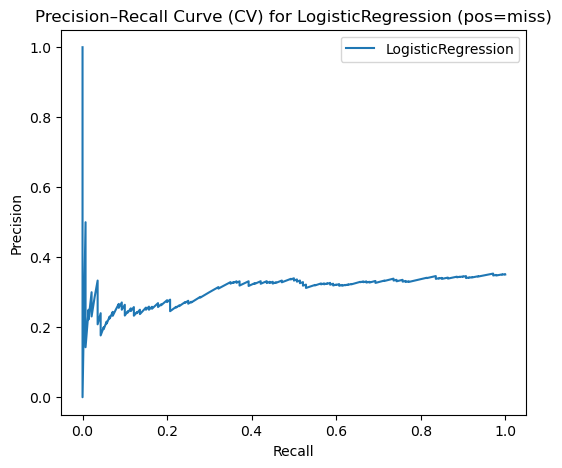

In [98]:
# =================================================
# B. During Model Building EDA
# =================================================
from sklearn.metrics import precision_recall_curve

CHOSEN_MODEL = "LogisticRegression"   # or any of your 7
POS_LABEL_INT = 0                     # 0=miss (positive), 1=make

def _final_estimator(est):
    # unwrap Pipeline -> get the last step "clf" if present
    if hasattr(est, "named_steps") and "clf" in est.named_steps:
        return est.named_steps["clf"]
    return est

# --- Feature importance (trees only) ---
if CHOSEN_MODEL in best_models:
    est = best_models[CHOSEN_MODEL]
    clf = _final_estimator(est)
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        idx = np.argsort(importances)[::-1][:15]
        plt.figure(figsize=(8,6))
        plt.barh(range(len(idx)), importances[idx])
        plt.yticks(range(len(idx)), X_train.columns[idx])
        plt.title(f"Top Features ({CHOSEN_MODEL})")
        plt.gca().invert_yaxis()
        plt.show()

# --- Precision–Recall Curve (robust to model type) ---
if CHOSEN_MODEL in best_models:
    from sklearn.model_selection import cross_val_predict
    est = best_models[CHOSEN_MODEL]
    clf = _final_estimator(est)

    if hasattr(clf, "predict_proba"):
        proba = cross_val_predict(est, X_train, y_train, cv=5, method="predict_proba")
        # classes_ for binary {0,1} are ordered [0,1]; our positive is class 0
        p_pos = proba[:, POS_LABEL_INT]
        scores = p_pos
    elif hasattr(clf, "decision_function"):
        df = cross_val_predict(est, X_train, y_train, cv=5, method="decision_function")
        # For binary, decision_function is positive for the class at classes_[1] (usually 1)
        # Our positive is 0 -> flip sign in 1D case
        if df.ndim == 1:
            scores = -df if POS_LABEL_INT == 0 else df
        else:
            scores = df[:, POS_LABEL_INT]
    else:
        scores = None
        print(f"[WARN] {CHOSEN_MODEL} has neither predict_proba nor decision_function; skipping PR curve.")

    if scores is not None:
        prec, rec, _ = precision_recall_curve(y_train, scores, pos_label=POS_LABEL_INT)
        plt.figure(figsize=(6,5))
        plt.plot(rec, prec, label=CHOSEN_MODEL)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve (CV) for {CHOSEN_MODEL} (pos=miss)")
        plt.legend()
        plt.show()


In [100]:
# =================================================
# Step 3: Calibration & Threshold Tuning  (pos class = 0 = 'miss')
# =================================================
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)
import numpy as np
import pandas as pd
from scipy.special import expit  # for decision_function -> prob mapping

PRECISION_FLOOR = 0.70  # precision floor used by one of the strategies

# ---------------------------
# Split training into sub-train / validation
# ---------------------------
X_subtr, X_val, y_subtr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# ---------------------------
# Helpers (POS_LABEL-aware)  -> everything uses POS_LABEL_INT = 0
# ---------------------------
def pick_threshold(p, y, precision_floor=None, tmin=0.05, tmax=0.95, n=181, pos_label=POS_LABEL_INT):
    """Grid-search a threshold on probabilities p to maximize F1 (optionally with a precision floor)."""
    ts = np.linspace(tmin, tmax, n)
    best = {"t": 0.5, "precision": 0.0, "recall": 0.0, "f1": -1.0}

    for t in ts:
        pred = (p >= t).astype(int)
        prec = precision_score(y, pred, pos_label=pos_label, zero_division=0)
        rec  = recall_score(y, pred,    pos_label=pos_label, zero_division=0)
        f1   = f1_score(y, pred,        pos_label=pos_label, zero_division=0)

        if precision_floor is None:
            if f1 > best["f1"]:
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}
        else:
            if (prec >= precision_floor) and (f1 > best["f1"]):
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}

    # fallback if precision_floor was too strict
    if precision_floor is not None and best["f1"] < 0:
        return pick_threshold(p, y, precision_floor=None, tmin=tmin, tmax=tmax, n=n, pos_label=pos_label)

    return best


def _classes_of(est):
    """Get classes_ from estimator or final step of Pipeline/GridSearch."""
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):  # Pipeline
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):  # GridSearchCV
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")


def pos_proba(est, X, pos_label=POS_LABEL_INT):
    """Return P(y == pos_label) for any fitted estimator/pipeline."""
    classes = list(_classes_of(est))

    if hasattr(est, "predict_proba"):
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]

    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        # Binary 1D case: scores are for classes_[1]; flip sign if our pos is classes_[0]
        if df.ndim == 1:
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)

    raise AttributeError("Estimator has neither predict_proba nor decision_function.")


# ---------------------------
# Calibration methods & strategies
# ---------------------------
calib_methods = ["none", "sigmoid", "isotonic"]  # added "none" for baseline
strategies = {
    "f1_max":    {"precision_floor": None},
    "f1_at_p70": {"precision_floor": PRECISION_FLOOR},
}

# ---------------------------
# Run calibration + thresholding
# ---------------------------
results = []

for model_name, base_model in best_models.items():
    for method in calib_methods:
        print(f"\n=== {model_name} | calibration={method} ===")

        if method == "none":
            # Use the base model directly (already tuned in step 2)
            model = base_model
            model.fit(X_subtr, y_subtr)
            p_val = pos_proba(model, X_val, pos_label=POS_LABEL_INT)
        else:
            # Wrap with calibration
            model = CalibratedClassifierCV(base_model, cv=5, method=method)
            model.fit(X_subtr, y_subtr)
            p_val = pos_proba(model, X_val, pos_label=POS_LABEL_INT)

        # Threshold strategies
        s1 = pick_threshold(p_val, y_val, **strategies["f1_max"])
        s2 = pick_threshold(p_val, y_val, **strategies["f1_at_p70"])

        # Threshold-free metrics (AP needs the pos_label; ROC doesn't)
        ap  = average_precision_score(y_val, p_val, pos_label=POS_LABEL_INT)
        roc = roc_auc_score(y_val, p_val)

        # Record both strategies
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_max",
            "best_threshold": s1["t"],
            "precision(miss)": s1["precision"],
            "recall(miss)": s1["recall"],
            "f1(miss)": s1["f1"],
            "AP(pos=miss)": ap,
            "ROC_AUC": roc
        })
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_at_p70",
            "best_threshold": s2["t"],
            "precision(miss)": s2["precision"],
            "recall(miss)": s2["recall"],
            "f1(miss)": s2["f1"],
            "AP(pos=miss)": ap,
            "ROC_AUC": roc
        })

# ---------------------------
# Display Model Performance
# ---------------------------
calib_threshold_df = (
    pd.DataFrame(results)
    .sort_values(by=["model", "calibration", "strategy"])
    .reset_index(drop=True)
)

print("\n[CALIBRATION / THRESHOLD COMPARISON]")
display(calib_threshold_df)

summary = (
    calib_threshold_df
    .sort_values(["model", "f1(miss)"], ascending=[True, False])
    .groupby("model")
    .head(2)
    .reset_index(drop=True)
)

print("\n[TOP CHOICES PER MODEL]")
display(summary)

# ---------------------------
# Save Models and Thresholds
# ---------------------------
fitted_models = {}
best_thresholds = {}

for model_name, base_model in best_models.items():
    for method in calib_methods:
        key = f"{model_name}_{method}"

        if method == "none":
            model = base_model
            model.fit(X_subtr, y_subtr)
        else:
            model = CalibratedClassifierCV(base_model, cv=5, method=method)
            model.fit(X_subtr, y_subtr)

        fitted_models[key] = model

        # compute probabilities of 'miss' (class 0)
        p_val = pos_proba(model, X_val, pos_label=POS_LABEL_INT)

        # choose your strategy (here: max F1 on validation)
        best = pick_threshold(p_val, y_val, precision_floor=None, pos_label=POS_LABEL_INT)
        best_thresholds[key] = best["t"]

# Save CSVs
calib_threshold_df.to_csv(run_dir / "calibration_threshold_grid.csv", index=False)
summary.to_csv(run_dir / "calibration_threshold_summary.csv", index=False)
print(f"[INFO] Saved: {run_dir/'calibration_threshold_grid.csv'} and {run_dir/'calibration_threshold_summary.csv'}")



=== LogisticRegression | calibration=none ===

=== LogisticRegression | calibration=sigmoid ===

=== LogisticRegression | calibration=isotonic ===

=== KNN | calibration=none ===

=== KNN | calibration=sigmoid ===

=== KNN | calibration=isotonic ===

=== DecisionTree | calibration=none ===

=== DecisionTree | calibration=sigmoid ===

=== DecisionTree | calibration=isotonic ===

=== RandomForest | calibration=none ===

=== RandomForest | calibration=sigmoid ===

=== RandomForest | calibration=isotonic ===

=== GradientBoosting | calibration=none ===

=== GradientBoosting | calibration=sigmoid ===

=== GradientBoosting | calibration=isotonic ===

=== SVM | calibration=none ===

=== SVM | calibration=sigmoid ===

=== SVM | calibration=isotonic ===

=== LinearSVC | calibration=none ===

=== LinearSVC | calibration=sigmoid ===

=== LinearSVC | calibration=isotonic ===

[CALIBRATION / THRESHOLD COMPARISON]


,model,calibration,strategy,best_threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC
0,DecisionTree,isotonic,f1_at_p70,0.385,0.373134,0.892857,0.526316,0.334807,0.553915
1,DecisionTree,isotonic,f1_max,0.385,0.373134,0.892857,0.526316,0.334807,0.553915
2,DecisionTree,none,f1_at_p70,0.730,0.346154,0.964286,0.509434,0.364477,0.476992
3,DecisionTree,none,f1_max,0.730,0.346154,0.964286,0.509434,0.364477,0.476992
4,DecisionTree,sigmoid,f1_at_p70,0.370,0.376812,0.928571,0.536082,0.372295,0.456731
5,DecisionTree,sigmoid,f1_max,0.370,0.376812,0.928571,0.536082,0.372295,0.456731
6,GradientBoosting,isotonic,f1_at_p70,0.460,0.364865,0.964286,0.529412,0.343500,0.538118
7,GradientBoosting,isotonic,f1_max,0.460,0.364865,0.964286,0.529412,0.343500,0.538118
8,GradientBoosting,none,f1_at_p70,0.445,0.403846,0.750000,0.525000,0.364800,0.526099
9,GradientBoosting,none,f1_max,0.445,0.403846,0.750000,0.525000,0.364800,0.526099



[TOP CHOICES PER MODEL]


,model,calibration,strategy,best_threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC
0,DecisionTree,sigmoid,f1_at_p70,0.370,0.376812,0.928571,0.536082,0.372295,0.456731
1,DecisionTree,sigmoid,f1_max,0.370,0.376812,0.928571,0.536082,0.372295,0.456731
2,GradientBoosting,isotonic,f1_at_p70,0.460,0.364865,0.964286,0.529412,0.343500,0.538118
3,GradientBoosting,isotonic,f1_max,0.460,0.364865,0.964286,0.529412,0.343500,0.538118
4,KNN,sigmoid,f1_at_p70,0.380,0.368421,1.000000,0.538462,0.320292,0.561813
5,KNN,sigmoid,f1_max,0.380,0.368421,1.000000,0.538462,0.320292,0.561813
6,LinearSVC,isotonic,f1_at_p70,0.380,0.363636,1.000000,0.533333,0.376007,0.451580
7,LinearSVC,isotonic,f1_max,0.380,0.363636,1.000000,0.533333,0.376007,0.451580
8,LogisticRegression,isotonic,f1_at_p70,0.385,0.368421,1.000000,0.538462,0.370737,0.456731
9,LogisticRegression,isotonic,f1_max,0.385,0.368421,1.000000,0.538462,0.370737,0.456731


[INFO] Saved: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/calibration_threshold_grid.csv and /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/calibration_threshold_summary.csv


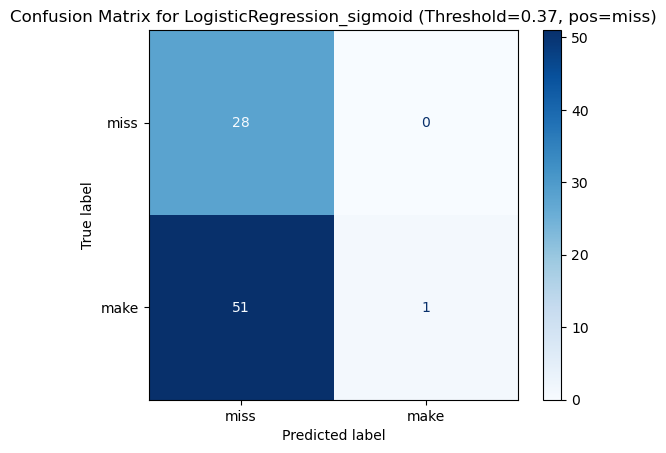

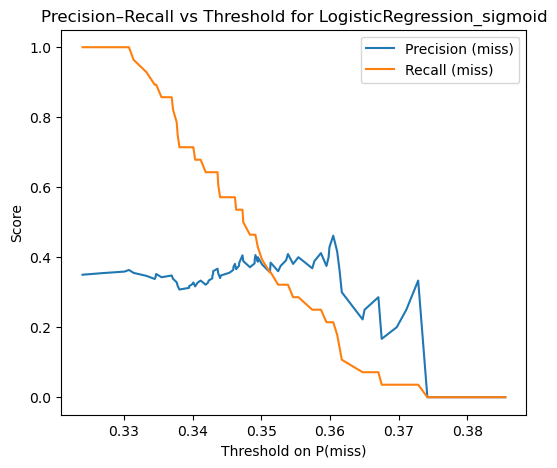

In [91]:
# =================================================
# C. After Thresholding & Calibration
# =================================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve

CHOSEN_MODEL = "LogisticRegression_sigmoid"

best_calib_model = fitted_models[CHOSEN_MODEL]
p_val = pos_proba(best_calib_model, X_val, pos_label=POS_LABEL_INT)

# --- Confusion Matrix ---
thres = best_thresholds[CHOSEN_MODEL]
y_pred_val = (p_val >= thres).astype(int)

cm = confusion_matrix(y_val, y_pred_val, labels=[0,1])  # keep 0=miss, 1=make
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix for {CHOSEN_MODEL} (Threshold={thres:.2f}, pos=miss)")
plt.show()

# --- Precision vs Recall curve (as function of threshold) ---
prec, rec, thr = precision_recall_curve(y_val, p_val, pos_label=POS_LABEL_INT)

plt.figure(figsize=(6,5))
plt.plot(thr, prec[:-1], label="Precision (miss)")
plt.plot(thr, rec[:-1], label="Recall (miss)")
plt.xlabel("Threshold on P(miss)")
plt.ylabel("Score")
plt.title(f"Precision–Recall vs Threshold for {CHOSEN_MODEL}")
plt.legend()
plt.show()


In [93]:
# =================================================
# Step 4: Full Training & Testing (Evaluation)
# =================================================
from joblib import dump
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)
from sklearn.base import clone
from scipy.special import expit  # for decision_function→prob mapping

# ----- Label constants (consistent across notebook) -----
LABELS = ["miss", "make"]   # 0 -> miss, 1 -> make
POS_LABEL_INT = 0           # positive class is 'miss'

# Use the train already built; keep test untouched
X_train_full = X_train
y_train_full = y_train

final_dir = run_dir / "final_eval"
final_dir.mkdir(parents=True, exist_ok=True)
print(f"[INFO] Saving final model evaluations to {final_dir}")

# Models to evaluate
chosen_models = [
    "LogisticRegression","KNN","DecisionTree",
    "RandomForest","GradientBoosting","SVM","LinearSVC",
]

# sanity checks
if 'best_models' not in globals():
    raise RuntimeError("best_models not found (run the hyperparameter tuning section first).")
if 'calib_threshold_df' not in globals():
    raise RuntimeError("calib_threshold_df not found (run the calibration/threshold section first).")

# --- utilities that respect pipelines and positive=0 ---
def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):  # Pipeline
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):  # GridSearchCV
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def pos_proba(clf, X, pos_label=POS_LABEL_INT):
    classes = list(_classes_of(clf))
    # try predict_proba
    if hasattr(clf, "predict_proba"):
        idx = classes.index(pos_label)
        return clf.predict_proba(X)[:, idx]
    # fallback: decision_function → logistic
    if hasattr(clf, "decision_function"):
        df = clf.decision_function(X)
        if df.ndim == 1:
            # sklearn’s binary margin is for classes_[1]; flip if our pos is classes_[0]
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

# Build: best calibration+threshold per model from calib_threshold_df
# (these column names assume you used the updated Step 3 names)
cfg_by_model = {}
for m in chosen_models:
    sub = calib_threshold_df[calib_threshold_df["model"] == m]
    if sub.empty:
        print(f"[WARN] No calibration rows for {m}; skipping.")
        continue
    row = sub.sort_values("f1(miss)", ascending=False).iloc[0]
    cfg_by_model[m] = {
        "calibration": row["calibration"],                     # "none" | "sigmoid" | "isotonic"
        "threshold": float(row["best_threshold"]),
        "strategy": row["strategy"],
        "val_F1(miss)": float(row["f1(miss)"]),
        "val_precision(miss)": float(row["precision(miss)"]),
        "val_recall(miss)": float(row["recall(miss)"]),
        "val_AP(pos=miss)": float(row["AP(pos=miss)"]),
        "val_ROC_AUC": float(row["ROC_AUC"]),
    }

final_results, saved_paths = [], []

for m in chosen_models:
    if m not in cfg_by_model:
        continue
    if m not in best_models:
        print(f"[WARN] No tuned pipeline in best_models for {m}; skipping.")
        continue

    base   = best_models[m]
    method = cfg_by_model[m]["calibration"]
    thr    = cfg_by_model[m]["threshold"]

    print(f"\n=== {m}: train full (calibration={method}, thr={thr:.3f}) ===")

    # Fit the final estimator on ALL training data
    if method == "none":
        final_est = clone(base).fit(X_train_full, y_train_full)
    else:
        final_est = CalibratedClassifierCV(clone(base), cv=5, method=method)
        final_est.fit(X_train_full, y_train_full)

    # predict on test (probabilities for 'miss' = class 0)
    p_test = pos_proba(final_est, X_test, pos_label=POS_LABEL_INT)  # P(miss)
    y_hat  = (p_test >= thr).astype(int)

    # metrics (treat 'miss' as positive = 0)
    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL_INT, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL_INT, zero_division=0)
    ap   = average_precision_score(y_test, p_test, pos_label=POS_LABEL_INT)
    roc  = roc_auc_score(y_test, p_test)
    bri  = brier_score_loss(y_test, p_test, pos_label=POS_LABEL_INT)  # IMPORTANT: pos_label=0 since p_test=P(miss)
    cm   = confusion_matrix(y_test, y_hat, labels=[0,1])

    print(f"[TEST] {m}  P(miss)={prec:.3f} R(miss)={rec:.3f} F1(miss)={f1:.3f}  AP(pos=miss)={ap:.3f}  ROC={roc:.3f}  Brier={bri:.3f}")
    print(pd.DataFrame(cm, index=["true miss (0)","true make (1)"], columns=["pred miss (0)","pred make (1)"]))

    # save model + plots
    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"
    dump(final_est, model_path)
    saved_paths.append(model_path.as_posix())

    try:
        fig_dir = final_dir / f"{m}_figs"
        save_all_eval_figures(
            outdir=fig_dir,
            y_true=y_test,
            y_pred=y_hat,
            y_proba=p_test,
            class_names=["miss (0)", "make (1)"]  # matches 0=miss, 1=make
        )
    except NameError:
        pass

    final_results.append({
        "model": m,
        "calibration": method,
        "threshold": thr,
        "val_metrics": cfg_by_model[m],
        "test_metrics": {
            "F1(miss)": float(f1),
            "precision(miss)": float(prec),
            "recall(miss)": float(rec),
            "AP(pos=miss)": float(ap),
            "ROC_AUC": float(roc),
            "Brier(pos=miss)": float(bri),
            "confusion_matrix": cm.tolist(),
        }
    })

# save summary
if final_results:
    final_df = pd.DataFrame([{
        "model": r["model"],
        "calibration": r["calibration"],
        "threshold": r["threshold"],
        "val_F1(miss)": r["val_metrics"]["val_F1(miss)"],
        "test_F1(miss)": r["test_metrics"]["F1(miss)"],
        "test_precision(miss)": r["test_metrics"]["precision(miss)"],
        "test_recall(miss)": r["test_metrics"]["recall(miss)"],
        "test_AP(pos=miss)": r["test_metrics"]["AP(pos=miss)"],
        "test_ROC_AUC": r["test_metrics"]["ROC_AUC"],
        "test_Brier(pos=miss)": r["test_metrics"]["Brier(pos=miss)"],
    } for r in final_results]).sort_values("test_F1(miss)", ascending=False).reset_index(drop=True)

    display(final_df)
    (final_dir / "final_results.json").write_text(json.dumps(final_results, indent=2))
    final_df.to_csv(final_dir / "final_results.csv", index=False)
    print(f"\n[INFO] Saved models:\n  - " + "\n  - ".join(saved_paths))
    print(f"[INFO] Results:\n  - {final_dir/'final_results.json'}\n  - {final_dir/'final_results.csv'}")
else:
    print("[WARN] Nothing trained—check chosen_models & that Step 3 produced calib_threshold_df rows.")


[INFO] Saving final model evaluations to /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval

=== LogisticRegression: train full (calibration=isotonic, thr=0.385) ===
[TEST] LogisticRegression  P(miss)=0.344 R(miss)=0.838 F1(miss)=0.488  AP(pos=miss)=0.446  ROC=0.424  Brier=0.229
               pred miss (0)  pred make (1)
true miss (0)             31              6
true make (1)             59              5


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== KNN: train full (calibration=sigmoid, thr=0.380) ===
[TEST] KNN  P(miss)=0.368 R(miss)=0.676 F1(miss)=0.476  AP(pos=miss)=0.375  ROC=0.491  Brier=0.233
               pred miss (0)  pred make (1)
true miss (0)             25             12
true make (1)             43             21


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== DecisionTree: train full (calibration=sigmoid, thr=0.370) ===
[TEST] DecisionTree  P(miss)=0.380 R(miss)=0.730 F1(miss)=0.500  AP(pos=miss)=0.401  ROC=0.474  Brier=0.233
               pred miss (0)  pred make (1)
true miss (0)             27             10
true make (1)             44             20


...

/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== LinearSVC: train full (calibration=isotonic, thr=0.380) ===
[TEST] LinearSVC  P(miss)=0.345 R(miss)=0.811 F1(miss)=0.484  AP(pos=miss)=0.475  ROC=0.395  Brier=0.225
               pred miss (0)  pred make (1)
true miss (0)             30              7
true make (1)             57              7


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


,model,calibration,threshold,val_F1(miss),test_F1(miss),test_precision(miss),test_recall(miss),test_AP(pos=miss),test_ROC_AUC,test_Brier(pos=miss)
0,RandomForest,none,0.560,0.562500,0.544000,0.386364,0.918919,0.390205,0.539696,0.254153
1,GradientBoosting,isotonic,0.460,0.529412,0.537313,0.371134,0.972973,0.344591,0.564189,0.237953
2,SVM,isotonic,0.425,0.533333,0.519685,0.366667,0.891892,0.418288,0.420819,0.232737
3,DecisionTree,sigmoid,0.370,0.536082,0.500000,0.380282,0.729730,0.400565,0.473818,0.233140
4,LogisticRegression,isotonic,0.385,0.538462,0.488189,0.344444,0.837838,0.446327,0.423986,0.228886
5,LinearSVC,isotonic,0.380,0.533333,0.483871,0.344828,0.810811,0.474710,0.395270,0.225318
6,KNN,sigmoid,0.380,0.538462,0.476190,0.367647,0.675676,0.375242,0.490921,0.232965



[INFO] Saved models:
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/LogisticRegression_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/KNN_cal-sigmoid.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/DecisionTree_cal-sigmoid.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/RandomForest_cal-none.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/GradientBoosting_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_18-12-47_run-001_baseline/final_eval/SVM_cal-isotonic.joblib
  - /Users/kwi

[Final Test Classification Report]  (positive = 'miss'=0)
              precision    recall  f1-score   support

    miss (0)       0.36      0.95      0.53        37
    make (1)       0.60      0.05      0.09        64

    accuracy                           0.38       101
   macro avg       0.48      0.50      0.31       101
weighted avg       0.51      0.38      0.25       101



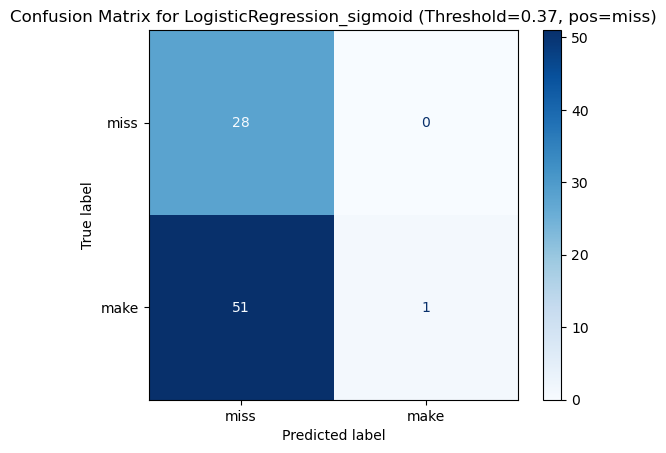

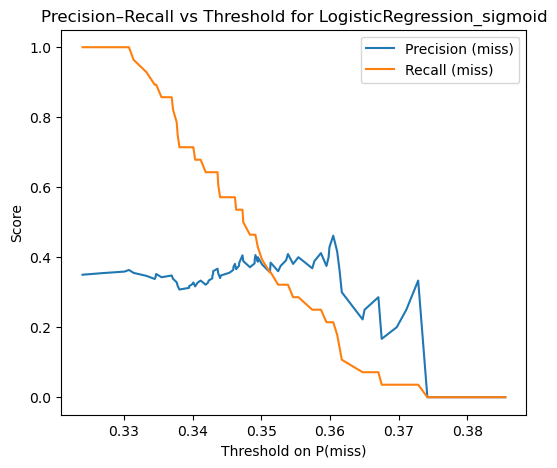

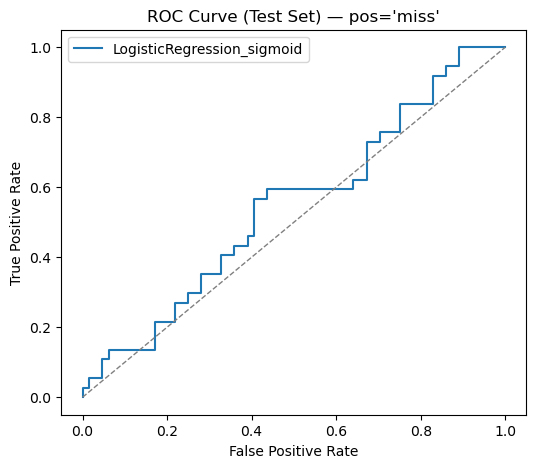

In [ ]:
# =================================================
# D. Final Test Evaluation  (pos class = 0 = 'miss')
# =================================================
from sklearn.metrics import classification_report, roc_curve

# Pick the calibrated model you want to report 
CHOSEN_MODEL = "LogisticRegression_sigmoid" 
final_model = fitted_models[CHOSEN_MODEL]
thr = best_thresholds[CHOSEN_MODEL]

# Probabilities for the positive class = miss (0)
POS_LABEL_INT = 0
LABELS = ["miss", "make"]  # display order for reports/CM

p_test = pos_proba(final_model, X_test, pos_label=POS_LABEL_INT)  # P(miss)
y_pred_test = (p_test >= thr).astype(int)

print("[Final Test Classification Report]  (positive = 'miss'=0)")
print(classification_report(
    y_test,
    y_pred_test,
    labels=[0, 1],                         # explicit order: 0 -> miss, 1 -> make
    target_names=["miss (0)", "make (1)"],
    zero_division=0
))

# --- Confusion Matrix ---
thres = best_thresholds[CHOSEN_MODEL]
y_pred_val = (p_val >= thres).astype(int)

cm = confusion_matrix(y_val, y_pred_val, labels=[0,1])  # keep 0=miss, 1=make
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix for {CHOSEN_MODEL} (Threshold={thres:.2f}, pos=miss)")
plt.show()

# --- Precision vs Recall curve (as function of threshold) ---
prec, rec, thr = precision_recall_curve(y_val, p_val, pos_label=POS_LABEL_INT)

plt.figure(figsize=(6,5))
plt.plot(thr, prec[:-1], label="Precision (miss)")
plt.plot(thr, rec[:-1], label="Recall (miss)")
plt.xlabel("Threshold on P(miss)")
plt.ylabel("Score")
plt.title(f"Precision–Recall vs Threshold for {CHOSEN_MODEL}")
plt.legend()
plt.show()

# Final ROC curve (using P(miss))
fpr, tpr, _ = roc_curve(y_test, p_test, pos_label=POS_LABEL_INT)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{CHOSEN_MODEL}")
plt.plot([0,1], [0,1], "--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Test Set) — pos='miss'")
plt.legend()
plt.show()


In [81]:
# ============================================================
# STEP 5: Diagnostics of final models  (pos class = 0 = 'miss')
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import load

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --------------------------
# Constants (keep consistent)
# --------------------------
LABELS = ["miss", "make"]   # 0 -> miss, 1 -> make
POS_LABEL_INT = 0

# --------------------------
# Paths & inputs
# --------------------------
final_dir = run_dir / "final_eval"
results_json = final_dir / "final_results.json"
if not results_json.exists():
    raise FileNotFoundError(f"Expected {results_json} from Step 4 at: {results_json}")

with results_json.open() as f:
    final_results = json.load(f)

X_train_full = X_train
y_train_full = y_train

diag_root = run_dir / "diagnostics_final"
diag_root.mkdir(parents=True, exist_ok=True)

if 'X_val' in globals() and 'y_val' in globals():
    use_X_perm, use_y_perm, perm_where = X_val, y_val, "val"
else:
    use_X_perm, use_y_perm, perm_where = X_test, y_test, "test"
print(f"[INFO] Permutation importance will run on: {perm_where} set")

# --------------------------
# POS_LABEL-aware helpers
# --------------------------
def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):  # Pipeline
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):  # GridSearchCV
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def _expit_stable(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, -35, 35)
    return 1.0 / (1.0 + np.exp(-x))

def pos_proba(est, X, pos_label=POS_LABEL_INT):
    """Return P(y == pos_label). Works with Pipeline; falls back to decision_function."""
    classes = list(_classes_of(est))
    if hasattr(est, "predict_proba"):
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]
    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        if df.ndim == 1:
            # sklearn margin is for classes_[1]; flip if our pos is classes_[0]
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return _expit_stable(s)
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

# --------------------------
# Picklable scorers for permutation_importance
# --------------------------
def perm_score_roc_auc(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL_INT)
    return roc_auc_score(y, p)

def perm_score_ap(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL_INT)
    return average_precision_score(y, p, pos_label=POS_LABEL_INT)

class ScorerF1AtThreshold:
    """Picklable callable for F1 at fixed threshold (pos=0)."""
    def __init__(self, threshold, pos_label=POS_LABEL_INT):
        self.threshold = float(threshold)
        self.pos_label = pos_label
    def __call__(self, est, X, y):
        p = pos_proba(est, X, pos_label=self.pos_label)
        yhat = (p >= self.threshold).astype(int)
        return f1_score(y, yhat, pos_label=self.pos_label, zero_division=0)

# --------------------------
# Permutation-importance wrapper
# --------------------------
def _permutation_importance_df(
    estimator, X_perm, y_perm, feature_names,
    mode="roc_auc",      # "roc_auc" | "average_precision" | "f1_at_threshold"
    threshold=None,
    n_repeats=30,
    n_jobs=-1
):
    if mode == "roc_auc":
        scoring = perm_score_roc_auc
    elif mode == "average_precision":
        scoring = perm_score_ap
    elif mode == "f1_at_threshold":
        if threshold is None:
            raise ValueError("threshold must be provided for f1_at_threshold")
        scoring = ScorerF1AtThreshold(threshold=threshold, pos_label=POS_LABEL_INT)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    res = permutation_importance(
        estimator, X_perm, y_perm,
        scoring=scoring, n_repeats=n_repeats,
        random_state=42, n_jobs=n_jobs
    )
    df = pd.DataFrame({
        "feature": feature_names,
        "perm_importance_mean": res.importances_mean,
        "perm_importance_std":  res.importances_std
    })
    return df.sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

# --------------------------
# Loop over final models
# --------------------------
summary_rows = []
feat_names = list(X_train_full.columns)

for entry in final_results:
    m        = entry["model"]
    method   = entry["calibration"]          # "none" | "sigmoid" | "isotonic"
    thr      = float(entry["threshold"])

    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"

    if not model_path.exists():
        print(f"[WARN] Missing saved model for {m} at {model_path}; skipping.")
        continue

    print(f"\n=== {m} | load final model | calibration={method} | threshold={thr:.3f} ===")
    cal = load(model_path)  # final trained (possibly calibrated) model

    # --- Performance on TEST (pos = 'miss' = 0) ---
    p_test = pos_proba(cal, X_test, pos_label=POS_LABEL_INT)  # P(miss)
    y_hat  = (p_test >= thr).astype(int)

    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL_INT, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL_INT, zero_division=0)
    ap   = average_precision_score(y_test, p_test, pos_label=POS_LABEL_INT)
    roc  = roc_auc_score(y_test, p_test)
    bri  = brier_score_loss(y_test, p_test, pos_label=POS_LABEL_INT)
    cm   = confusion_matrix(y_test, y_hat, labels=[0, 1])

    # With labels=[0,1], cm = [[C00, C01],[C10, C11]]
    # For pos=0: TP = C00, FN = C01, FP = C10, TN = C11
    C00, C01, C10, C11 = cm.ravel()
    tp_miss, fn_miss, fp_miss, tn_miss = int(C00), int(C01), int(C10), int(C11)

    print(f"[TEST] P(miss)={prec:.3f} R(miss)={rec:.3f} F1(miss)={f1:.3f}  AP(pos=miss)={ap:.3f}  ROC={roc:.3f}  Brier(pos=miss)={bri:.3f}")
    print(pd.DataFrame(cm,
        index=["true miss (0)","true make (1)"],
        columns=["pred miss (0)","pred make (1)"]
    ))

    # --- Save plots (if your util exists) ---
    outdir = (diag_root / m)
    figdir = outdir / "figs"
    outdir.mkdir(parents=True, exist_ok=True)
    try:
        save_all_eval_figures(
            figdir,
            y_true=y_test,
            y_pred=y_hat,
            y_proba=p_test,
            class_names=["miss (0)", "make (1)"]
        )
    except NameError:
        pass

    # --- Save predictions & errors ---
    errs = X_test.copy()
    errs["y_true"] = y_test.values
    errs["y_prob_miss"] = p_test
    errs["y_pred"] = y_hat
    errs["error_type"] = np.where(
        (errs["y_true"] == POS_LABEL_INT) & (errs["y_pred"] != POS_LABEL_INT), "FN",  # missed a miss
        np.where((errs["y_true"] != POS_LABEL_INT) & (errs["y_pred"] == POS_LABEL_INT), "FP", "OK")
    )
    try:
        errs["session"] = session_test.values
    except Exception:
        pass
    errs.to_csv(outdir / "predictions_with_errors.csv", index=False)
    errs[errs["error_type"].isin(["FP","FN"])].to_csv(outdir / "misclassified_only.csv", index=False)

    # --- Permutation importances ---
    perm_auc = _permutation_importance_df(
        cal, use_X_perm, use_y_perm, feat_names,
        mode="roc_auc", n_repeats=30, n_jobs=-1
    )
    perm_auc.to_csv(outdir / f"importance_perm_rocauc_on_{perm_where}.csv", index=False)

    perm_f1thr = _permutation_importance_df(
        cal, use_X_perm, use_y_perm, feat_names,
        mode="f1_at_threshold", threshold=thr, n_repeats=30, n_jobs=-1
    )
    perm_f1thr.to_csv(outdir / f"importance_perm_f1_thr{thr:.3f}_on_{perm_where}.csv", index=False)

    # --- Config snapshot + summary row ---
    meta = {
        "model": m,
        "calibration": method,
        "threshold": thr,
        "val_metrics_from_step4": entry.get("val_metrics", {}),
        "test_metrics": {
            "precision(miss)": float(prec),
            "recall(miss)": float(rec),
            "f1(miss)": float(f1),
            "AP(pos=miss)": float(ap),
            "ROC_AUC": float(roc),
            "Brier(pos=miss)": float(bri),
            "confusion_matrix": cm.tolist(),
            "tp_miss": tp_miss, "fn_miss": fn_miss, "fp_miss": fp_miss, "tn_miss": tn_miss
        }
    }
    (outdir / "config_metrics.json").write_text(json.dumps(meta, indent=2))

    summary_rows.append({
        "model": m, "calibration": method, "threshold": thr,
        "precision(miss)": float(prec), "recall(miss)": float(rec), "f1(miss)": float(f1),
        "AP(pos=miss)": float(ap), "ROC_AUC": float(roc), "Brier(pos=miss)": float(bri),
        "perm_top_feature_rocauc": (perm_auc.iloc[0]["feature"] if len(perm_auc) else None),
        "perm_top_feature_f1thr": (perm_f1thr.iloc[0]["feature"] if len(perm_f1thr) else None),
    })

# --------------------------
# Roll-up table
# --------------------------
if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("f1(miss)", ascending=False).reset_index(drop=True)
    display(summary_df)
    summary_df.to_csv(diag_root / "summary_across_models.csv", index=False)
    print(f"\n[INFO] Diagnostics written under: {diag_root}")
else:
    print("[WARN] No models diagnosed — check Step 4 outputs in", final_dir)


[INFO] Permutation importance will run on: val set

=== LogisticRegression | load final model | calibration=isotonic | threshold=0.385 ===
[TEST] P(miss)=0.344 R(miss)=0.838 F1(miss)=0.488  AP(pos=miss)=0.446  ROC=0.424  Brier(pos=miss)=0.229
               pred miss (0)  pred make (1)
true miss (0)             31              6
true make (1)             59              5


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== KNN | load final model | calibration=none | threshold=0.640 ===
[TEST] P(miss)=0.360 R(miss)=0.973 F1(miss)=0.526  AP(pos=miss)=0.434  ROC=0.431  Brier(pos=miss)=0.236
               pred miss (0)  pred make (1)
true miss (0)             36              1
true make (1)             64              0


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== DecisionTree | load final model | calibration=isotonic | threshold=0.365 ===
[TEST] P(miss)=0.339 R(miss)=0.541 F1(miss)=0.417  AP(pos=miss)=0.375  ROC=0.502  Brier(pos=miss)=0.232
               pred miss (0)  pred make (1)
true miss (0)             20             17
true make (1)             39             25


...

/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== LinearSVC | load final model | calibration=isotonic | threshold=0.380 ===
[TEST] P(miss)=0.345 R(miss)=0.811 F1(miss)=0.484  AP(pos=miss)=0.475  ROC=0.395  Brier(pos=miss)=0.225
               pred miss (0)  pred make (1)
true miss (0)             30              7
true make (1)             57              7


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


,model,calibration,threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC,Brier(pos=miss),perm_top_feature_rocauc,perm_top_feature_f1thr
0,KNN,none,0.640,0.360000,0.972973,0.525547,0.434297,0.430532,0.235824,shoulder_flex_l_release_value,elbow_flex_l_release_value
1,GradientBoosting,isotonic,0.445,0.360000,0.972973,0.525547,0.399075,0.536318,0.236045,windup_duration,elbow_flex_r_release_value
2,RandomForest,isotonic,0.465,0.357143,0.945946,0.518519,0.403053,0.479730,0.232474,ankle_flex_l_release_value,shoulder_flex_l_release_value
3,LogisticRegression,isotonic,0.385,0.344444,0.837838,0.488189,0.446327,0.423986,0.228886,windup_duration,ankle_flex_r_release_value
4,LinearSVC,isotonic,0.380,0.344828,0.810811,0.483871,0.474710,0.395270,0.225318,elbow_flex_l_release_value,ankle_flex_r_release_value
5,SVM,sigmoid,0.380,0.349398,0.783784,0.483333,0.381367,0.514358,0.233322,elbow_flex_l_release_value,elbow_flex_l_release_value
6,DecisionTree,isotonic,0.365,0.338983,0.540541,0.416667,0.375170,0.501900,0.232330,ankle_flex_l_release_value,knee_flex_r_release_value



[INFO] Diagnostics written under: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-28_15-35-03_run-001_baseline/diagnostics_final


In [ ]:
# ===== Step 6: Feature Pruning from Permutation Importance =====
import re
import pandas as pd
from pathlib import Path

# --- Config you can tweak ---
EXPERIMENT = "2025-08-28_13-14-04_run-001_baseline"   # <-- set your experiment id
PERM_SET   = "val"                                     # "val" or "test"
THRESHOLD  = 0.01                                      # keep if mean_importance >= THRESHOLD (after clipping negatives)

# --- Paths ---
# Assumes MODEL_TYPE already defined in your notebook/environment (e.g., "summary_stats")
EXPERIMENT_DIR = Path("../experiments") / MODEL_TYPE / EXPERIMENT
IMPORTANCE_DIR = EXPERIMENT_DIR / "diagnostics_final"
OUTPUT_LIST    = EXPERIMENT_DIR / "reduced_features.csv"
OUTPUT_MERGED  = EXPERIMENT_DIR / "feature_importance_merged.csv"

if not EXPERIMENT_DIR.exists():
    raise FileNotFoundError(f"[ERROR] Experiment dir not found: {EXPERIMENT_DIR}")
if not IMPORTANCE_DIR.exists():
    raise FileNotFoundError(f"[ERROR] Diagnostics dir not found: {IMPORTANCE_DIR}")

# --- Collect permutation CSVs (supports rocauc + f1_at_threshold) ---
# e.g., .../ModelName/importance_perm_rocauc_on_val.csv
#       .../ModelName/importance_perm_f1_thr0.432_on_val.csv
pattern = f"**/importance_perm_*_on_{PERM_SET}.csv"
files = list(IMPORTANCE_DIR.glob(pattern))
if not files:
    raise FileNotFoundError(f"No permutation CSVs found under {IMPORTANCE_DIR} ({pattern})")

rows = []
for f in files:
    model = f.parent.name
    # capture between 'importance_perm_' and '_on_val' or '_on_test'
    m = re.search(rf"importance_perm_(.+)_on_{PERM_SET}\.csv$", f.name)
    raw_metric = m.group(1) if m else "unknown"

    # Normalize metric name (collapse f1_thr{...} → f1_at_threshold)
    if raw_metric.startswith("f1_thr"):
        metric = "f1_at_threshold"
    else:
        metric = raw_metric  # e.g., "rocauc", "average_precision" if you added it

    df = pd.read_csv(f)
    expected = {"feature", "perm_importance_mean", "perm_importance_std"}
    if not expected.issubset(df.columns):
        raise ValueError(f"Unexpected columns in {f}: {df.columns.tolist()} (expected {sorted(expected)})")

    tmp = df[["feature", "perm_importance_mean", "perm_importance_std"]].copy()
    tmp["metric"] = metric
    tmp["model"]  = model
    rows.append(tmp)

long_df = pd.concat(rows, ignore_index=True)

# Clip negatives (perm importance can go negative from noise)
long_df["perm_importance_mean"] = long_df["perm_importance_mean"].clip(lower=0)

# --- Aggregate across models for each (feature, metric) ---
agg_df = (
    long_df
    .groupby(["feature", "metric"], as_index=False)
    .agg(
        mean_over_models=("perm_importance_mean", "mean"),
        std_over_models =("perm_importance_mean", "std"),
        models_count    =("model", "nunique"),
    )
)

# --- Pivot to wide: columns per metric (averaged across models) ---
wide = agg_df.pivot_table(
    index="feature",
    columns="metric",
    values="mean_over_models",
    aggfunc="first"
).fillna(0.0)

# flatten columns
wide.columns = [f"mean_{c}" for c in wide.columns]
wide = wide.reset_index()

# overall mean across all metric columns
mean_cols = [c for c in wide.columns if c.startswith("mean_")]
wide["mean_importance"] = wide[mean_cols].mean(axis=1)

# --- Filter by threshold and save ---
reduced = wide[wide["mean_importance"] >= THRESHOLD].sort_values("mean_importance", ascending=False)

# Ensure parent dirs exist (usually already do)
OUTPUT_LIST.parent.mkdir(parents=True, exist_ok=True)

# Save outputs
reduced["feature"].to_csv(OUTPUT_LIST, index=False)
wide.sort_values("mean_importance", ascending=False).to_csv(OUTPUT_MERGED, index=False)

# --- Logs / preview ---
print(f"[INFO] Files loaded: {len(files)} from {IMPORTANCE_DIR} (set={PERM_SET})")
print(f"[INFO] Metrics detected: {sorted({c.replace('mean_','') for c in mean_cols})}")
print(f"[INFO] Features kept: {len(reduced)} / {len(wide)}  (threshold={THRESHOLD})")
if not reduced.empty:
    print("[TOP 10 kept features]")
    print(reduced[["feature", "mean_importance"]].head(10).to_string(index=False))
print(f"[INFO] Saved reduced list -> {OUTPUT_LIST}")
print(f"[INFO] Saved merged table -> {OUTPUT_MERGED}")


[INFO] Files loaded: 14
[INFO] Features kept: 5 / 13 (threshold=0.01)
[INFO] Saved reduced list -> ../experiments/summary_stats/2025-08-28_13-14-04_run-001_baseline/reduced_features.csv
[INFO] Saved merged table -> ../experiments/summary_stats/2025-08-28_13-14-04_run-001_baseline/feature_importance_merged.csv
